In [2]:
#Next assignments:
#perform the time series analysis on
#1)Monthly Cola Production in Australia 2) ice cream sales 3)usd to inr 

In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as  sns

In [5]:
#step1 : finding the avilable dataset
df=pd.read_csv("ice_cream.csv")

In [7]:
print(df.head())

         date     sale
0  1972-01-01  59.9622
1  1972-02-01  67.0605
2  1972-03-01  74.2350
3  1972-04-01  78.1120
4  1972-05-01  84.7636


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    577 non-null    object 
 1   sale    577 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.1+ KB


In [10]:
#ensuring the time date column is in the correct format
#the frequency should be correct

In [11]:
#now making the date column as the index
df['date']=pd.to_datetime(df['date'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    577 non-null    datetime64[ns]
 1   sale    577 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 9.1 KB


In [13]:
#now making the date column as the index
df.set_index('date',inplace=True)

In [14]:
print(df.head())

               sale
date               
1972-01-01  59.9622
1972-02-01  67.0605
1972-03-01  74.2350
1972-04-01  78.1120
1972-05-01  84.7636


<Axes: xlabel='date', ylabel='sale'>

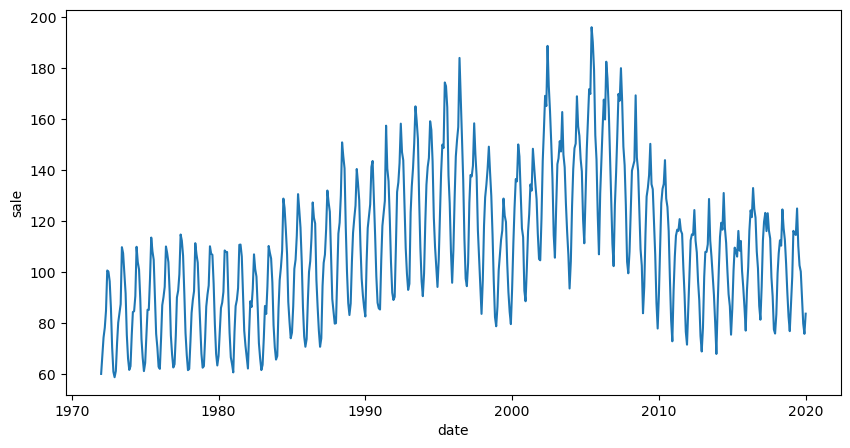

In [16]:
#now we need to visualize it 
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x=df.index,y=df.sale)

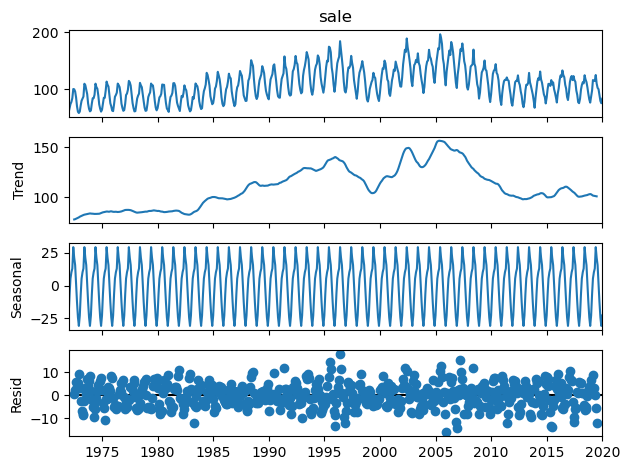

In [17]:
#now further checking the sesonality and trend by doing decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(df.sale,period=12)
fig=decomposition.plot()
plt.show()

### checking if the time series is stationary

In [19]:
df['rollMean']=df.sale.rolling(window=12).mean()
df['rollStd']=df.sale.rolling(window=12).std()

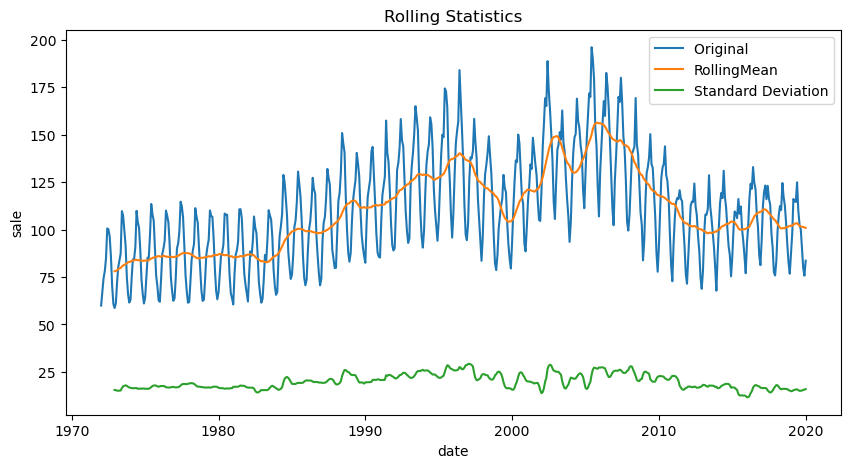

In [20]:
#plotting the original data with the rolling mean and std
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x=df.index,y=df.sale,label="Original ")
sns.lineplot(data=df,x=df.index,y=df.rollMean,label='RollingMean')
sns.lineplot(data=df,x=df.index,y=df.rollStd,label="Standard Deviation")
plt.title("Rolling Statistics")
plt.show()

In [21]:
#the time series is not in a stationary

In [22]:
#checking the same using a function

In [33]:
#Define the same using a function
def test_stationary(dataFrame,var):
    dataFrame['rollMean']=dataFrame[var].rolling(window=12).mean()
    dataFrame['rollStd']=dataFrame[var].rolling(window=12).std()
    from statsmodels.tsa.stattools import adfuller
    adf_result=adfuller(dataFrame[var])
    p_value=adf_result[1]
    print(f"ADF p-value:{p_value:.4f}")
    if p_value < 0.05:
        print("The time series is stationary(Reject HO)")
    else:
        print("The time series is not stationary(Fail to reject HO)")
    #plot the original series with rolling mean and std
    plt.figure(figsize=(10,5))
    sns.lineplot(data=dataFrame,x=dataFrame.index,y=var,label='Original')
    sns.lineplot(data=dataFrame,x=dataFrame.index,y='rollMean',label='Rolling Mean')
    sns.lineplot(data=dataFrame,x=dataFrame.index,y='rollStd',label='Rolling Std')
    plt.title("Stationary check using Rolling mean and Std Dev")
    plt.legend()
    plt.show()

ADF p-value:0.4015
The time series is not stationary(Fail to reject HO)


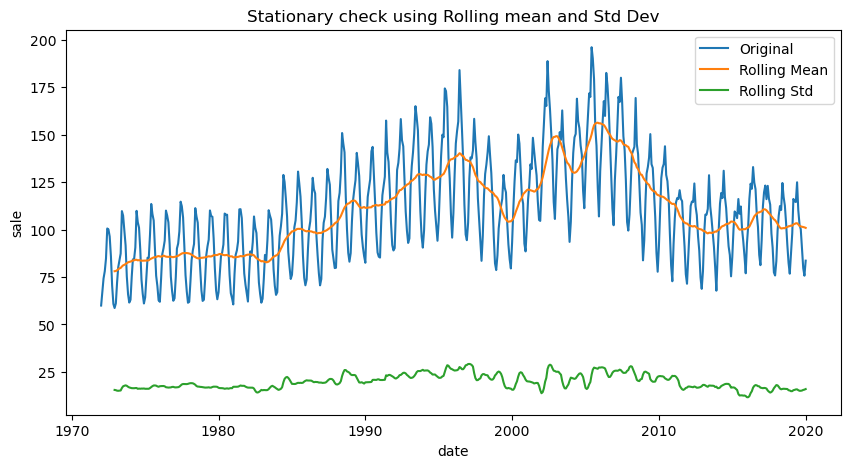

In [34]:
test_stationary(df,'sale')

In [35]:
sale_df=df[['sale']].copy()

In [36]:
sale_df['shift']=sale_df.sale.shift(1)
sale_df['shiftDiff']=sale_df['sale']-sale_df['shift']
print(sale_df.head())

               sale    shift  shiftDiff
date                                   
1972-01-01  59.9622      NaN        NaN
1972-02-01  67.0605  59.9622     7.0983
1972-03-01  74.2350  67.0605     7.1745
1972-04-01  78.1120  74.2350     3.8770
1972-05-01  84.7636  78.1120     6.6516


C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_12172\1668182394.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean']=dataFrame[var].rolling(window=12).mean()
C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_12172\1668182394.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd']=dataFrame[var].rolling(window=12).std()


ADF p-value:0.0000
The time series is stationary(Reject HO)


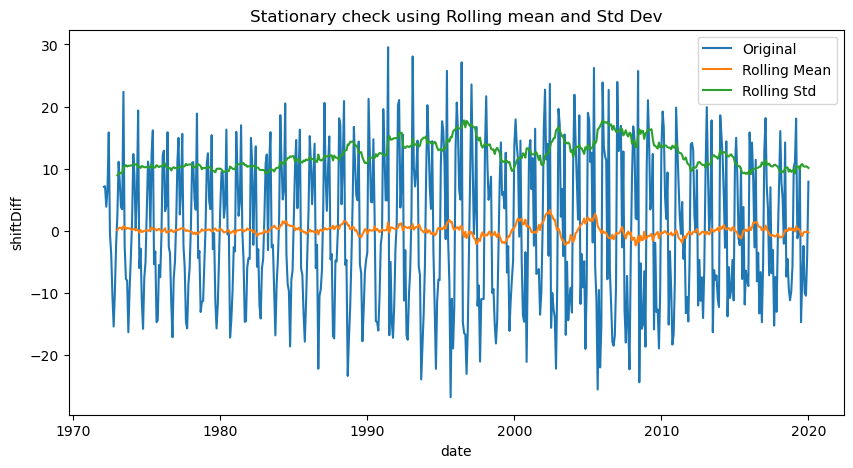

In [37]:
test_stationary(sale_df.dropna(),'shiftDiff')

In [38]:
sale_df['shift']=sale_df.sale.shift(2)
sale_df['shiftDiff']=sale_df['sale']-sale_df['shift']
print(sale_df.head())

               sale    shift  shiftDiff
date                                   
1972-01-01  59.9622      NaN        NaN
1972-02-01  67.0605      NaN        NaN
1972-03-01  74.2350  59.9622    14.2728
1972-04-01  78.1120  67.0605    11.0515
1972-05-01  84.7636  74.2350    10.5286


C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_12172\1668182394.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean']=dataFrame[var].rolling(window=12).mean()
C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_12172\1668182394.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd']=dataFrame[var].rolling(window=12).std()


ADF p-value:0.0000
The time series is stationary(Reject HO)


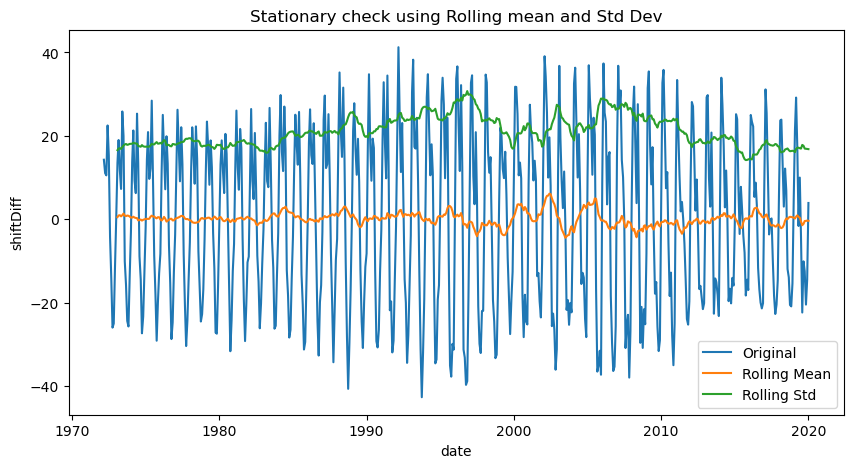

In [40]:
test_stationary(sale_df.dropna(),'shiftDiff')

In [41]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

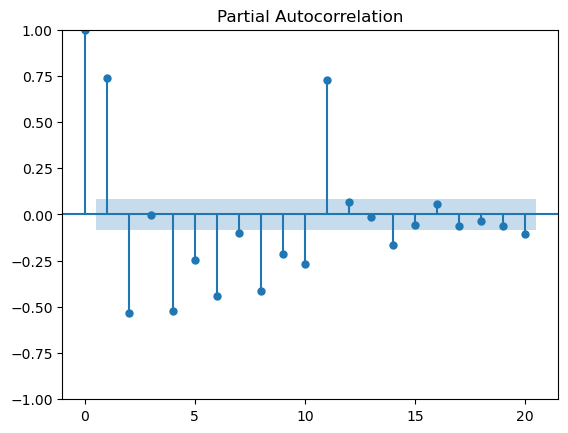

In [42]:
plot_pacf(sale_df['shiftDiff'].dropna(),lags=20)
plt.show()

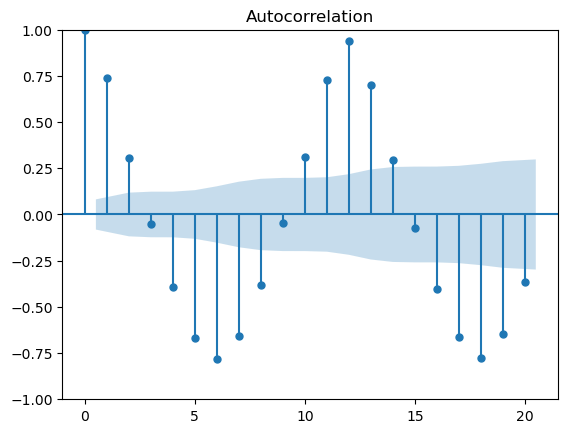

In [43]:
plot_acf(sale_df['shiftDiff'].dropna(),lags=20)
plt.show()

In [44]:
train= sale_df[:round(len(sale_df)*70/100)] #Take the first 70% data
print(train.tail()) 

                sale     shift  shiftDiff
date                                     
2005-04-01  171.8314  148.1976    23.6338
2005-05-01  169.9522  159.2750    10.6772
2005-06-01  196.1737  171.8314    24.3423
2005-07-01  190.2501  169.9522    20.2979
2005-08-01  179.2849  196.1737   -16.8888


In [45]:
test = sale_df[round(len(sale_df)*70/100):] #Take the last 30 % data starting from 71%
print(test.head())

                sale     shift  shiftDiff
date                                     
2005-09-01  153.7389  190.2501   -36.5112
2005-10-01  144.2127  179.2849   -35.0722
2005-11-01  122.2164  153.7389   -31.5225
2005-12-01  106.9509  144.2127   -37.2618
2006-01-01  130.8295  122.2164     8.6131


In [48]:
model = ARIMA(train['sale'],order=(1,2,1)) #Parameters: p,d,q
model_fit= model.fit()
prediction= model_fit.predict(start=test.index[0],end=test.index[-1])
sale_df['arimaPred']=prediction
print(sale_df.tail())

C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                sale     shift  shiftDiff   arimaPred
date                                                 
2019-09-01  100.1741  110.2632   -10.0891  215.740260
2019-10-01   90.1684  102.6085   -12.4401  216.024985
2019-11-01   79.7223  100.1741   -20.4518  216.309710
2019-12-01   75.7094   90.1684   -14.4590  216.594435
2020-01-01   83.6290   79.7223     3.9067  216.879161


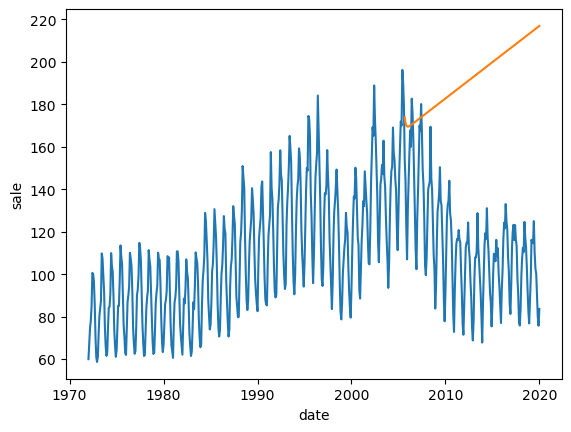

In [49]:
sns.lineplot(data=sale_df,x=sale_df.index,y='sale')
sns.lineplot(data=sale_df,x=sale_df.index,y='arimaPred')
plt.show()


In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train['sale'],order=(1,2,1),seasonal_order=(1,2,1,12))
model_fit = model.fit()
prediction = model_fit.predict(start=test.index[0],end=test.index[-1])
sale_df['sarimaxPred']=prediction
print(sale_df.tail())

C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                sale     shift  shiftDiff   arimaPred  sarimaxPred
date                                                              
2019-09-01  100.1741  110.2632   -10.0891  215.740260   830.767894
2019-10-01   90.1684  102.6085   -12.4401  216.024985   831.605167
2019-11-01   79.7223  100.1741   -20.4518  216.309710   816.154375
2019-12-01   75.7094   90.1684   -14.4590  216.594435   805.609425
2020-01-01   83.6290   79.7223     3.9067  216.879161   832.193925


               sale    shift  shiftDiff  arimaPred  sarimaxPred
date                                                           
1972-01-01  59.9622      NaN        NaN        NaN          NaN
1972-02-01  67.0605      NaN        NaN        NaN          NaN
1972-03-01  74.2350  59.9622    14.2728        NaN          NaN
1972-04-01  78.1120  67.0605    11.0515        NaN          NaN
1972-05-01  84.7636  74.2350    10.5286        NaN          NaN


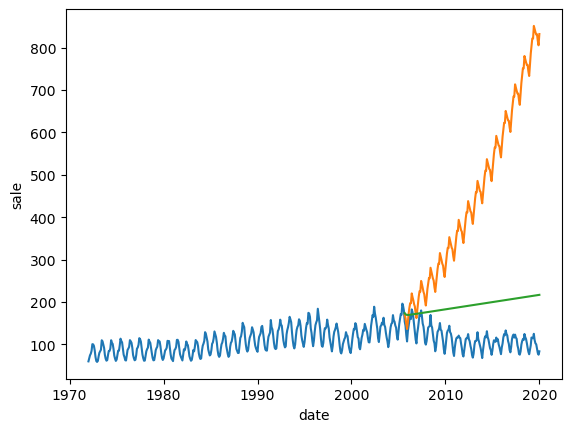

In [53]:
sale_df.dropna()
print(sale_df.head())
sns.lineplot(data=sale_df,x=sale_df.index,y='sale')
sns.lineplot(data=sale_df,x=sale_df.index,y='sarimaxPred')
sns.lineplot(data=sale_df,x=sale_df.index,y='arimaPred')
plt.show()